In [9]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/hotel_bookings.csv')

df.info()

df.isnull().sum()

df.describe()

df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

np.int64(31994)

#Seasonality Analysis

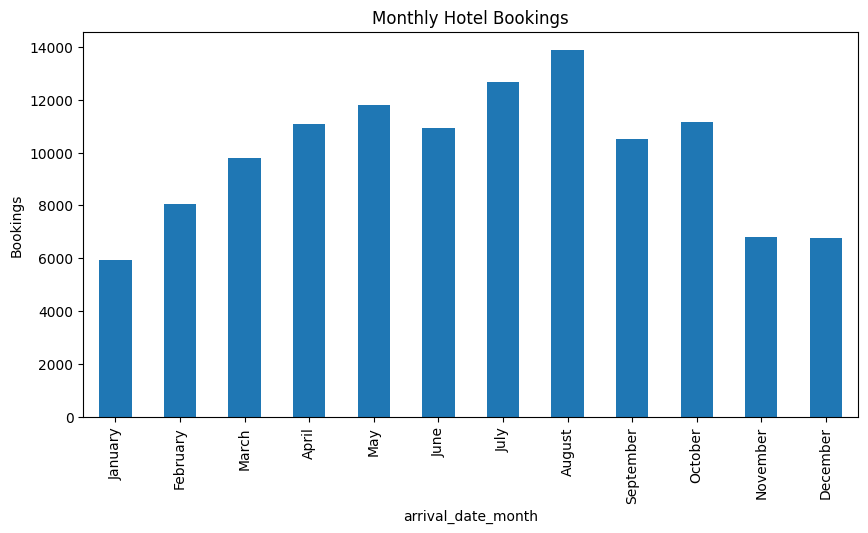

In [26]:
import matplotlib.pyplot as plt

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly = (
    df.groupby("arrival_date_month")
      .size()
      .reindex(month_order)
)

plt.figure(figsize=(10,5))
monthly.plot(kind="bar")
plt.title("Monthly Hotel Bookings")
plt.ylabel("Bookings")
plt.show()

In [31]:
monthly = df.groupby("arrival_date_month").agg(
    bookings=("hotel","count"),
    adr=("adr","mean"),
    cancellation=("is_canceled","mean")
).reindex(month_order)

monthly

,bookings,adr,cancellation
arrival_date_month,,,
January,5929,70.361241,0.304773
February,8068,73.582276,0.334160
March,9794,80.679646,0.321523
April,11089,100.380790,0.407972
May,11791,108.695516,0.396658
June,10939,116.672192,0.414572
July,12661,126.788013,0.374536
August,13877,140.111523,0.377531
September,10508,105.049657,0.391702


Insigh

1.宿泊需要は春から夏にかけて継続的に増加し、8月が年間で最も予約件数（13,877件）およびADR（140.1）ともに最高となった。

2.一方、1月から3月、および11月から12月は予約件数・ADRともに低く、ホテル需要には明確な季節性が見られる。

3.また、4月〜6月は予約数の増加とともにキャンセル率も40%前後まで上昇しており、需要拡大とキャンセルリスクが同時に高まる時期であることが分かった。
Business Recommendation

1.繁忙期（7〜8月）は需要が高いため、ダイナミックプライシングを活用し、ADRおよびRevPARの最大化を目指す。

2.4月〜6月はキャンセル率が高いため、早期予約向けの返金不可プランやリマインド施策を導入し、キャンセルリスクを抑制する。

3.閑散期（11〜2月）は期間限定プロモーションやターゲット別キャンペーンを実施し、稼働率向上を図る。

# Market Segment & Cancellation Analysis

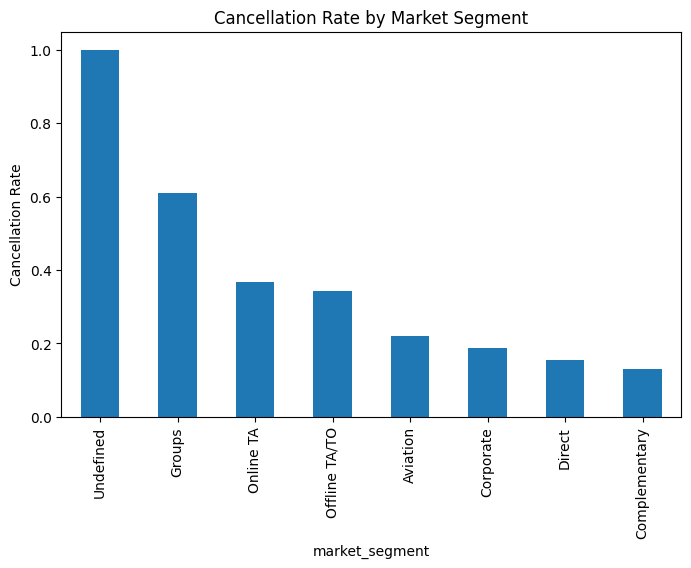

In [27]:
cancel = (
    df.groupby("market_segment")["is_canceled"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
cancel.plot(kind="bar")
plt.title("Cancellation Rate by Market Segment")
plt.ylabel("Cancellation Rate")
plt.show()

In [32]:
cancel_summary = df.groupby("market_segment").agg(
    booking=("hotel","count"),
    cancel_rate=("is_canceled","mean"),
    lead_time=("lead_time","mean"),
    adr=("adr","mean")
)

cancel_summary

,booking,cancel_rate,lead_time,adr
market_segment,,,,
Aviation,237,0.219409,4.443038,100.142110
Complementary,743,0.130552,13.286676,2.886366
Corporate,5295,0.187347,22.125590,69.358952
Direct,12606,0.153419,49.859115,115.445175
Groups,19811,0.610620,186.973096,79.479472
Offline TA/TO,24219,0.343160,135.004459,87.354783
Online TA,56477,0.367211,82.998725,117.197063
Undefined,2,1.000000,1.500000,15.000000


**Insight**

1.Online TA は全セグメントの中で最も多くの予約（56,477件）を獲得しており、ADRも117.2と高い一方、キャンセル率は36.7%と比較的高い。

2.Groups は平均Lead Timeが187日と最も長く、キャンセル率も61.1%と突出して高い。

3.Direct はADRが115.4と高水準でありながら、キャンセル率は15.3%と低く、最も質の高い予約チャネルの一つである。

**Business Impact**

1.Online TAはホテル売上への貢献度が非常に高い一方、キャンセルによる収益機会損失も大きい。

2.Groupsは将来需要を確保できる反面、キャンセル率が高く、在庫管理や売上予測を難しくする要因となる。

**Business Recommendation**

1.Online TAでは返金不可プランや早期予約割引を活用し、予約品質の向上を図る。

2.Groupsにはデポジット制度や段階的な予約確認を導入し、大量キャンセルのリスクを低減する。

3.Direct Bookingはキャンセル率が低く収益性も高いため、ロイヤルティプログラムや会員限定特典を強化し、Direct比率を高める。

In [28]:
lead = (
    df.groupby("market_segment")["lead_time"]
      .mean()
      .sort_values(ascending=False)
)

lead

,lead_time
market_segment,
Groups,186.973096
Offline TA/TO,135.004459
Online TA,82.998725
Direct,49.859115
Corporate,22.125590
Complementary,13.286676
Aviation,4.443038
Undefined,1.500000


In [33]:
bins=[0,30,60,90,180,365,1000]

labels=[
"0-30",
"31-60",
"61-90",
"91-180",
"181-365",
">365"
]

df["lead_group"]=pd.cut(
    df["lead_time"],
    bins=bins,
    labels=labels
)

lead_cancel=df.groupby("lead_group")["is_canceled"].mean()

lead_cancel

/tmp/ipykernel_2333/1795426951.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lead_cancel=df.groupby("lead_group")["is_canceled"].mean()


,is_canceled
lead_group,
0-30,0.208739
31-60,0.363819
61-90,0.394739
91-180,0.447105
181-365,0.554540
>365,0.676620


**Insight**

1.Lead Timeが長くなるほどキャンセル率は一貫して上昇する傾向が確認された。
予約から30日以内ではキャンセル率は約21%だったが、365日以上前に予約した場合は約68%まで上昇している。

2.これは、宿泊日までの期間が長いほど予定変更や価格比較などによりキャンセルが発生しやすいことを示唆している。

**Business Impact**

長期先予約は将来の需要予測には有効である一方、キャンセルリスクも高く、ホテルの在庫管理や価格戦略へ大きな影響を与える。

**Business Recommendation**

1.Lead Timeが長い予約に対しては、宿泊前のリマインドメールや限定オファーを配信し、宿泊意欲を維持する。

2.長期予約についてはデポジット制度やキャンセルポリシーを最適化し、キャンセル率の改善を図る。
キャンセル予測モデルを活用し、高リスク予約を早期に特定することで、空室販売機会を最大化する。

# Revenue Contribution Analysis

In [34]:
segment = df.groupby("market_segment").agg(
    bookings=("hotel","count"),
    adr=("adr","mean")
)

segment["estimated_revenue"] = \
segment["bookings"] * segment["adr"]

segment.sort_values(
    "estimated_revenue",
    ascending=False
)

,bookings,adr,estimated_revenue
market_segment,,,
Online TA,56477,117.197063,6618938.52
Offline TA/TO,24219,87.354783,2115645.48
Groups,19811,79.479472,1574567.82
Direct,12606,115.445175,1455301.88
Corporate,5295,69.358952,367255.65
Aviation,237,100.142110,23733.68
Complementary,743,2.886366,2144.57
Undefined,2,15.000000,30.00


**Insight**

1.Online TA は全チャネルの中で最も高い推定売上（約662万）を生み出しており、ホテル収益を支える最も重要な販売チャネルである。

2.一方で、Online TA は予約件数・ADRともに高い反面、キャンセル率も36.7%と比較的高く、売上拡大と予約品質の両立が重要な課題である。

3.Direct Booking は予約件数こそ少ないものの、高いADRと低いキャンセル率を維持しており、安定した収益源として高い価値を持つ。

4.この結果から、各チャネルには異なる特徴があり、一律の販売戦略ではなく、チャネルごとの最適化が必要であることが分かった。

**Business Recommendation**

1.Agodaとしては、Online TA の集客力を最大限に活用しながら、ホテルパートナーと連携して料金戦略やプロモーションを最適化し、売上の最大化を支援する。

2.また、返金不可プランや早期予約キャンペーンなどを活用し、予約品質を改善することで、キャンセルによる機会損失を削減する。

3.チャネル別の売上・ADR・キャンセル率を継続的に分析し、それぞれの特性に応じた販売戦略を提案することで、ホテルパートナーの長期的な収益向上に貢献する。

================================================================================

# Executive Summary
**Project Objective**

本分析では、ホテル予約データを用いて、ホテルパートナーの売上最大化とキャンセル率の改善に向けた施策を検討した。

**Key Findings**

宿泊需要には明確な季節性があり、7〜8月は予約件数・ADRともに最も高く、ホテル収益の最大化が期待できる時期である。

Online TA は最も多くの予約と売上を生み出す主要チャネルである一方、キャンセル率も比較的高く、予約品質の改善が重要な課題である。

Lead Time が長くなるほどキャンセル率が上昇する傾向が見られ、早期予約の管理がホテル運営において重要であることが確認できた。

Direct Booking は高いADRと低いキャンセル率を維持しており、安定した収益チャネルとして価値が高い。

**Recommendations**

繁忙期にはダイナミックプライシングを活用し、ADRおよび収益を最大化する。

Online TAでは返金不可プランや価格最適化を通じて、予約品質を向上させ、キャンセル率を改善する。

Lead Time が長い予約については、リマインダーやデポジット制度などの施策を導入し、キャンセルリスクを低減する。

チャネルごとのパフォーマンスを継続的に分析し、ホテルパートナーに対してデータに基づく販売戦略を提案する。

**Conclusion**

本分析を通じて、データ分析は単に現状を把握するためではなく、ホテルパートナーのビジネス課題を特定し、具体的な改善施策を提案するための手段であることを確認した。

Agoda Strategic Account Managerとして重要なのは、予約件数だけではなく、ADR・キャンセル率・チャネル特性など複数の指標を総合的に分析し、ホテルパートナーの収益最大化につながる戦略を提案することである。